# Minimal Transformer Demo: Key-Value Lookup

This notebook trains a tiny transformer on a synthetic key-value lookup task.

Each training example looks like this:

```text
[CLS] K3 V7 K1 V4 K8 V2 [QUERY] K1
```

The model must predict the value belonging to the query key. In the example above, the answer is `V4`.

Why this dataset is useful for education:

- It is generated on the fly, so there is no dataset download.
- It trains quickly, usually in seconds on an A100 and still comfortably under 10 minutes on modest GPUs.
- The task requires routing information across positions, which is exactly what self-attention is designed to show.
- The final cell visualizes attention from the query token so you can inspect what the model learned.


In [1]:
import math
import random
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## Prerequisites

The notebook expects PyTorch and Matplotlib:

```bash
pip install torch matplotlib
```

## Token Vocabulary

The vocabulary has special tokens, key tokens, and value tokens. Keys and values are intentionally separate token ranges so the model cannot solve the task by simple token identity.


In [2]:
PAD = 0
CLS = 1
QUERY = 2

num_keys = 16
num_values = 16
num_pairs = 6

key_offset = 3
value_offset = key_offset + num_keys
vocab_size = value_offset + num_values

seq_len = 1 + 2 * num_pairs + 2  # [CLS], key/value pairs, [QUERY], query key

def key_token(k):
    return key_offset + k

def value_token(v):
    return value_offset + v

def token_name(t):
    t = int(t)
    if t == PAD:
        return "[PAD]"
    if t == CLS:
        return "[CLS]"
    if t == QUERY:
        return "[QUERY]"
    if key_offset <= t < value_offset:
        return f"K{t - key_offset}"
    return f"V{t - value_offset}"

vocab_size, seq_len


(35, 15)

## Data Generator

Every batch is generated randomly. The model sees many different mappings, so it must learn the operation: find the queried key and return the value next to it.


In [3]:
def make_batch(batch_size):
    x = torch.empty(batch_size, seq_len, dtype=torch.long)
    y = torch.empty(batch_size, dtype=torch.long)

    for b in range(batch_size):
        keys = random.sample(range(num_keys), num_pairs)
        values = random.sample(range(num_values), num_pairs)
        query_index = random.randrange(num_pairs)
        query_key = keys[query_index]
        answer_value = values[query_index]

        tokens = [CLS]
        for k, v in zip(keys, values):
            tokens.extend([key_token(k), value_token(v)])
        tokens.extend([QUERY, key_token(query_key)])

        x[b] = torch.tensor(tokens, dtype=torch.long)
        y[b] = answer_value

    return x.to(device), y.to(device)

sample_x, sample_y = make_batch(3)
[[token_name(t) for t in row] for row in sample_x.cpu()], sample_y.cpu().tolist()


([['[CLS]',
   'K11',
   'V12',
   'K14',
   'V15',
   'K1',
   'V11',
   'K13',
   'V4',
   'K6',
   'V10',
   'K12',
   'V13',
   '[QUERY]',
   'K1'],
  ['[CLS]',
   'K5',
   'V9',
   'K11',
   'V13',
   'K6',
   'V14',
   'K1',
   'V15',
   'K13',
   'V5',
   'K8',
   'V4',
   '[QUERY]',
   'K6'],
  ['[CLS]',
   'K7',
   'V12',
   'K13',
   'V9',
   'K11',
   'V11',
   'K10',
   'V10',
   'K0',
   'V7',
   'K14',
   'V13',
   '[QUERY]',
   'K11']],
 [11, 14, 11])

## Tiny Transformer

This is an encoder-only transformer classifier. It predicts the answer from the final hidden state at the query-key token, which is the final token in the sequence.

The self-attention module stores its attention matrix so we can visualize it later.


In [4]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out = nn.Linear(d_model, d_model)
        self.last_attention = None

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        qkv = self.qkv(x)
        qkv = qkv.view(batch_size, seq_len, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        scores = q @ k.transpose(-2, -1) / math.sqrt(self.head_dim)
        attention = scores.softmax(dim=-1)
        self.last_attention = attention.detach()

        context = attention @ v
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        return self.out(context)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, num_heads)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
        )
        self.ln2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x + self.dropout(self.attn(self.ln1(x)))
        x = x + self.dropout(self.ff(self.ln2(x)))
        return x


class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model=64, num_heads=4, num_layers=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(seq_len, d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_values)

    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        h = self.token_embedding(x) + self.position_embedding(positions)
        for block in self.blocks:
            h = block(h)
        h = self.ln(h)
        return self.head(h[:, -1])


model = TinyTransformer(vocab_size, seq_len).to(device)
sum(p.numel() for p in model.parameters())


71312

## Train

On an A100 this should finish far below the 10 minute target. The defaults are intentionally small so the notebook is also usable on CPU, though CPU will be slower.


In [8]:
batch_size = 512
steps = 1200
learning_rate = 1e-3

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

start = time.time()
history = []

for step in range(1, steps + 1):
    model.train()
    x, y = make_batch(batch_size)
    logits = model(x)
    loss = F.cross_entropy(logits, y)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if step % 100 == 0 or step == 1:
        model.eval()
        with torch.no_grad():
            vx, vy = make_batch(4096)
            v_logits = model(vx)
            acc = (v_logits.argmax(dim=-1) == vy).float().mean().item()
        history.append((step, loss.item(), acc))
        print(f"step {step:4d} | loss {loss.item():.4f} | validation accuracy {acc:.3f}")

elapsed = time.time() - start
print(f"training time: {elapsed:.1f}s on {device}")


step    1 | loss 1.8766 | validation accuracy 0.162
step  100 | loss 1.8645 | validation accuracy 0.159
step  200 | loss 1.8744 | validation accuracy 0.166
step  300 | loss 1.8408 | validation accuracy 0.178
step  400 | loss 1.8092 | validation accuracy 0.242
step  500 | loss 1.1874 | validation accuracy 0.601
step  600 | loss 0.2616 | validation accuracy 0.953
step  700 | loss 0.0703 | validation accuracy 0.997
step  800 | loss 0.0438 | validation accuracy 0.999
step  900 | loss 0.0243 | validation accuracy 1.000
step 1000 | loss 0.0366 | validation accuracy 1.000
step 1100 | loss 0.0037 | validation accuracy 1.000
step 1200 | loss 0.0016 | validation accuracy 1.000
training time: 126.5s on cpu


## Inspect Predictions


In [6]:
model.eval()
x, y = make_batch(8)
with torch.no_grad():
    pred = model(x).argmax(dim=-1)

for row, target, guess in zip(x.cpu(), y.cpu(), pred.cpu()):
    tokens = " ".join(token_name(t) for t in row)
    print(f"{tokens} -> target V{int(target):02d}, predicted V{int(guess):02d}")


[CLS] K1 V0 K9 V9 K15 V7 K10 V5 K6 V13 K8 V4 [QUERY] K15 -> target V07, predicted V07
[CLS] K13 V7 K1 V12 K5 V14 K4 V3 K8 V8 K2 V1 [QUERY] K2 -> target V01, predicted V07
[CLS] K3 V0 K1 V5 K10 V6 K15 V14 K14 V8 K2 V13 [QUERY] K15 -> target V14, predicted V05
[CLS] K8 V4 K11 V5 K0 V14 K12 V1 K13 V7 K6 V3 [QUERY] K8 -> target V04, predicted V01
[CLS] K6 V14 K8 V8 K1 V5 K11 V0 K9 V15 K10 V10 [QUERY] K1 -> target V05, predicted V05
[CLS] K7 V1 K5 V12 K0 V13 K9 V5 K14 V4 K4 V9 [QUERY] K5 -> target V12, predicted V13
[CLS] K1 V12 K8 V13 K15 V15 K0 V0 K4 V11 K5 V7 [QUERY] K15 -> target V15, predicted V11
[CLS] K3 V3 K5 V4 K6 V13 K2 V12 K7 V2 K8 V6 [QUERY] K8 -> target V06, predicted V04


## Visualize Attention

The heatmap below shows attention from each output position to each input position for one head in the final transformer block. Try changing `head_index` or `example_index`.

Useful rows to inspect:

- The query key at the final position, because the classifier reads from this position.
- Value tokens next to the matching earlier key, because the model must recover one of them.


sequence: [CLS] K15 V1 K12 V7 K4 V10 K14 V2 K10 V12 K13 V4 [QUERY] K13
target: V04, predicted: V12


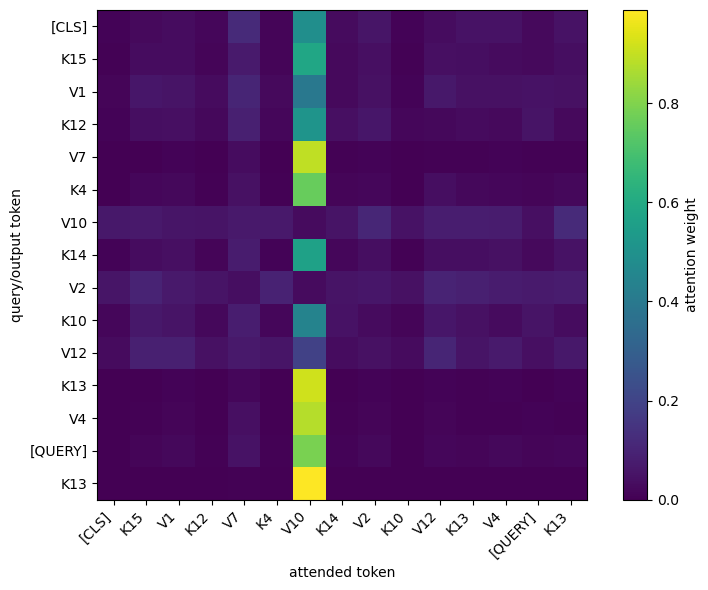

In [7]:
example_index = 0
head_index = 3

model.eval()
x, y = make_batch(1)
with torch.no_grad():
    logits = model(x)
    prediction = logits.argmax(dim=-1).item()

attention = model.blocks[-1].attn.last_attention[example_index, head_index].cpu()
labels = [token_name(t) for t in x[example_index].cpu()]

print("sequence:", " ".join(labels))
print(f"target: V{int(y.item()):02d}, predicted: V{prediction:02d}")

plt.figure(figsize=(8, 6))
plt.imshow(attention, cmap="viridis", vmin=0, vmax=attention.max())
plt.xticks(range(seq_len), labels, rotation=45, ha="right")
plt.yticks(range(seq_len), labels)
plt.xlabel("attended token")
plt.ylabel("query/output token")
plt.colorbar(label="attention weight")
plt.tight_layout()
plt.show()
